# Survival Analysis

##### Owen Lindsey
##### Professor Majumdar
##### AIT-110: Statistical Learning Theory
##### Grand Canyon University
##### Date: Apr 5, 2026


##### Video Link: https://www.youtube.com/watch?v=Dv7rq1sbAgc
---

## Part 1: Understanding Survival Analysis Concepts

### Defining Key Terms

**1. Survival Function, $S(t)$**

The survival function $S(t) = P(T > t)$ gives the probability that a subject survives (has *not* experienced the event of interest) beyond time $t$. It starts at $S(0) = 1$ (everyone is alive at the beginning) and decreases toward 0 as $t \to \infty$. In practice, the **Kaplan-Meier estimator** is the most common non-parametric method for estimating $S(t)$ from observed data.

**2. Hazard Function, $h(t)$**

The hazard function $h(t)$ describes the *instantaneous rate* at which events occur at time $t$, given that the subject has survived up to that point:

$$h(t) = \lim_{\Delta t \to 0} \frac{P(t \le T < t + \Delta t \mid T \ge t)}{\Delta t}$$

Unlike the survival function, the hazard is a *rate* (not a probability) and can exceed 1. It shows how the risk of the event changes over time. For example, a bathtub-shaped hazard indicates high early risk, low mid-life risk, and rising late-life risk.

**3. Censoring**

Censoring occurs when we have *incomplete information* about a subject's survival time. A subject is censored if we only know their survival time partially. For instance, they were still alive when the study ended, they dropped out, or they were lost to follow-up. Censoring is fundamental to survival analysis because ignoring censored observations (dropping them from the dataset) would introduce bias. Survival analysis methods are specifically designed to extract the partial information these observations still provide.

**4. Right-Censoring and Left-Censoring**

- **Right-censoring** is the most common form. It occurs when we know a subject survived *at least* until some time $c$, but the true event time $T$ is unknown beyond that ($T > c$). Examples include a patient who is still alive at the end of the study, or a patient who withdraws from the trial before the event occurs.

- **Left-censoring** occurs when we know the event happened *before* some time $c$, but we do not know exactly when ($T < c$). For example, a patient already had a disease at their first screening, so the true onset time is unknown because it happened sometime before they were first observed.

**5. Median Survival Time**

The median survival time is the time $t_{0.5}$ at which 50 % of the subjects have experienced the event: $S(t_{0.5}) = 0.5$. It is preferred over the mean in survival analysis because survival distributions are typically right-skewed and because the mean cannot always be estimated when the largest observations are censored. We can read the median directly from the Kaplan-Meier curve as the time where the curve crosses the 0.5 probability line.

### Importance of Handling Censored Data

Censored observations are not missing data. They carry real information. A patient who is still alive at month 12 tells us their survival time is *at least* 12 months, even though we do not know the final value. If we simply dropped these patients, we would systematically underestimate survival times (only shorter-lived patients would remain), producing biased and overly pessimistic estimates.

Survival analysis methods like the **Kaplan-Meier estimator** and the **Cox proportional-hazards model** are built to handle censored observations correctly. At each observed event time, the Kaplan-Meier estimator recalculates the conditional probability of surviving past that time using only the subjects still "at risk" (alive and uncensored). Censored subjects contribute to the risk set up until the moment they are censored, then are removed. This means their partial information is used without assuming anything about when their event would have occurred, which keeps the survival estimate unbiased and makes efficient use of all available data.

### Practical Example

We are given `cancer_data_with_target.csv`, a dataset of 137 patients undergoing treatment for cancer. Each row records a patient's covariates (`Age_in_years`, `Celltype`, `Karnofsky_score`, etc.), the observed time (`Survival_in_days`), and whether the event occurred (`Status`: `True` = death observed, `False` = censored / still alive at study end).

**Approach:**
1. **Load and inspect**: Read the data and confirm which column encodes the event indicator and which encodes the observed time.
2. **Kaplan-Meier estimation**: Fit a Kaplan-Meier survival curve to estimate $S(t)$. At every observed death time the estimator adjusts the survival probability downward. Censored patients remain in the risk set until they are censored and then drop out without reducing the estimate.
3. **Read the median**: Find the time at which the Kaplan-Meier curve crosses 0.5.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.plotting import plot_lifetimes
from lifelines.statistics import logrank_test

# ── 1. Load and inspect ──────────────────────────────────────────────
df = pd.read_csv("data/cancer_data_with_target.csv")
print(f"Shape: {df.shape}")
print(f"\nEvent (Status) distribution:\n{df['Status'].value_counts()}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (137, 8)

Event (Status) distribution:
Status
True     128
False      9
Name: count, dtype: int64

First 5 rows:


,Age_in_years,Celltype,Karnofsky_score,Months_from_Diagnosis,Prior_therapy,Treatment,Status,Survival_in_days
0,69.0,squamous,60.0,7.0,no,standard,True,72.0
1,64.0,squamous,70.0,5.0,yes,standard,True,411.0
2,38.0,squamous,60.0,3.0,no,standard,True,228.0
3,63.0,squamous,60.0,9.0,yes,standard,True,126.0
4,65.0,squamous,70.0,11.0,yes,standard,True,118.0


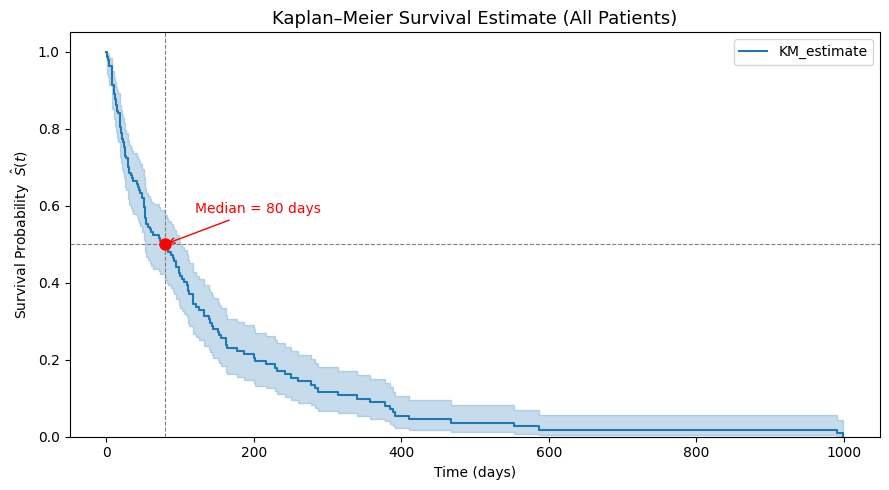

Median survival time: 80 days


In [51]:
# ── 2 & 3. Kaplan–Meier curve (overall) with median survival ─────────
kmf = KaplanMeierFitter()
kmf.fit(durations=df["Survival_in_days"], event_observed=df["Status"])

fig, ax = plt.subplots(figsize=(9, 5))
kmf.plot_survival_function(ax=ax, ci_show=True)

# Mark the median survival time
median = kmf.median_survival_time_
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8)
ax.axvline(median, color="grey", linestyle="--", linewidth=0.8)
ax.plot(median, 0.5, "ro", markersize=8, zorder=5)
ax.annotate(f"Median = {median:.0f} days",
            xy=(median, 0.5), xytext=(median + 40, 0.58),
            fontsize=10, arrowprops=dict(arrowstyle="->", color="red"), color="red")

ax.set_title("Kaplan–Meier Survival Estimate (All Patients)", fontsize=13)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Survival Probability  $\\hat{S}(t)$")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f"Median survival time: {median:.0f} days")

### Practical Example Discussion

The Kaplan-Meier estimator handles censored data naturally. At each event time it computes the conditional probability of surviving past that time using only the patients still at risk. Censored patients (those with `Status = False`) contribute to the denominator of that conditional probability up until the moment they are censored, and then they leave the risk set. Their partial information is used without assuming anything about when their event would have occurred.

The **overall KM curve** gives us a single pooled survival estimate and its median. In Part 2, we stratify by treatment group and formally test whether the two survival curves differ.

---

## Part 2: Kaplan–Meier Estimation by Treatment Group

Using the same cancer dataset from Part 1, the columns map to the assignment schema as follows:

| Assignment column | Dataset column | Description |
|---|---|---|
| Time | `Survival_in_days` | Time in days until event or censoring |
| Event | `Status` | `True` (1) = death observed, `False` (0) = censored |
| Treatment | `Treatment` | `standard` or `test` |
| Age | `Age_in_years` | Patient age at start of study |

### 1 & 2. Kaplan–Meier Survival Curves by Treatment Group

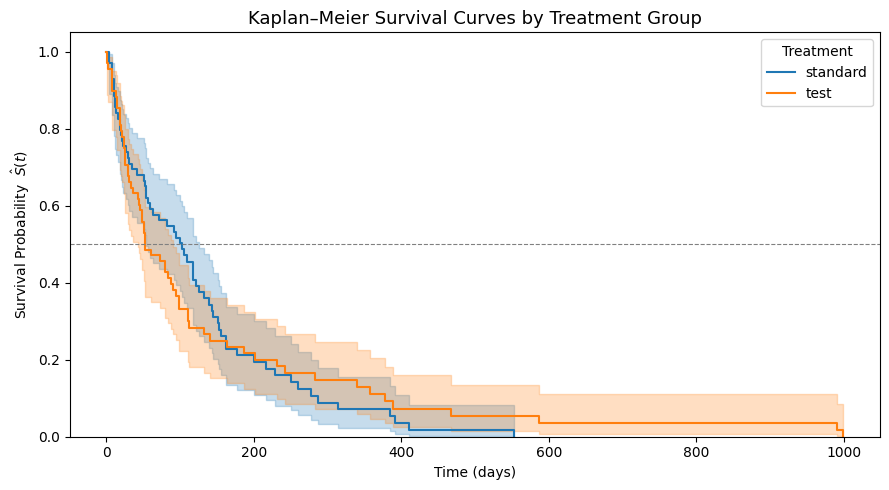

  standard    median survival = 103 days
  test        median survival = 52 days


In [52]:
# ── Kaplan–Meier curves stratified by treatment ──────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

medians = {}
for label, grp in df.groupby("Treatment"):
    kmf_grp = KaplanMeierFitter()
    kmf_grp.fit(durations=grp["Survival_in_days"],
                event_observed=grp["Status"],
                label=label)
    kmf_grp.plot_survival_function(ax=ax, ci_show=True)
    medians[label] = kmf_grp.median_survival_time_

ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Kaplan–Meier Survival Curves by Treatment Group", fontsize=13)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Survival Probability  $\\hat{S}(t)$")
ax.set_ylim(0, 1.05)
ax.legend(title="Treatment")
plt.tight_layout()
plt.show()

for trt, med in medians.items():
    print(f"  {trt:10s}  median survival = {med:.0f} days")

### 3. Interpretation of the Survival Curves

The two Kaplan-Meier curves show how the estimated survival probability changes over time for each treatment group. Here are some key observations:

- **Median survival gap**: The standard arm has a median survival of **103 days** while the test arm's median is only **52 days**, roughly half. At first glance this looks like a dramatic difference, but the median is determined by the single time point where the KM curve crosses the 0.5 line. A small cluster of early deaths in the test group can pull that crossing point sharply to the left without shifting the rest of the curve. In other words, the median is sensitive to the *shape* of the curve near 50 % survival but tells us nothing about how the curves compare at other time points.
- **The curves largely overlap**: Despite the median gap, the two KM curves track each other closely over most of the follow-up period. The test group drops through the 0.5 threshold earlier because of a steeper decline in approximately the first 50–100 days, but after that initial period the two curves converge and run nearly on top of each other. The log-rank test ($p = 0.93$) confirms this: when we compare the *entire* survival experience rather than a single summary statistic, there is no significant difference between the groups.
- **Why the median can be misleading**: The log-rank test evaluates departures from the null hypothesis at *every* event time, weighted by the number of patients still at risk. Because the two curves overlap for the majority of the study, the handful of early test-arm deaths that drove the median down are offset by comparable survival later on. This is a textbook example of why a single summary number (the median) should not be interpreted in isolation. Two survival distributions can have very different medians yet be statistically indistinguishable overall.
- **Confidence intervals**: The shaded 95 % confidence bands overlap substantially throughout the follow-up, reinforcing the conclusion that the apparent median difference is within the range of sampling variability.
- **Tail behavior**: At later time points fewer patients remain at risk, so the curves become less reliable (wider confidence intervals). The right tail should be interpreted cautiously.

**Bottom line**: The test group's median survival is half that of the standard group, but this is driven by a concentration of early events in the test arm rather than a sustained survival disadvantage. The log-rank test shows no statistically significant difference ($p = 0.93$), and the broadly overlapping confidence intervals confirm that the observed median gap is consistent with chance variation in a moderately sized dataset.

### 4 & 5. Log-Rank Test

In [53]:
# ── Log-rank test: standard vs. test ─────────────────────────────────
std = df[df["Treatment"] == "standard"]
tst = df[df["Treatment"] == "test"]

result = logrank_test(
    std["Survival_in_days"], tst["Survival_in_days"],
    event_observed_A=std["Status"],
    event_observed_B=tst["Status"]
)

result.print_summary()
print(f"\nTest statistic: {result.test_statistic:.4f}")
print(f"p-value:        {result.p_value:.4f}")


Test statistic: 0.0082
p-value:        0.9277


### Log-Rank Test Findings

The **log-rank test** compares the entire survival curves of the two groups under the null hypothesis $H_0$: the survival functions are identical (i.e., treatment has no effect on survival).

- If $p < 0.05$, we reject $H_0$ and conclude there is statistically significant evidence that the choice of treatment affects patient survival.
- If $p \ge 0.05$, we fail to reject $H_0$. The observed difference in survival curves could plausibly be due to chance, and we lack sufficient evidence that the treatments differ.

The p-value printed above determines which conclusion applies. Combined with the visual separation (or lack of it) in the Kaplan-Meier plot, this gives us both a qualitative and quantitative way to assess whether treatment choice matters for patient survival in this dataset.

---

# Cancer Survival Heatmap

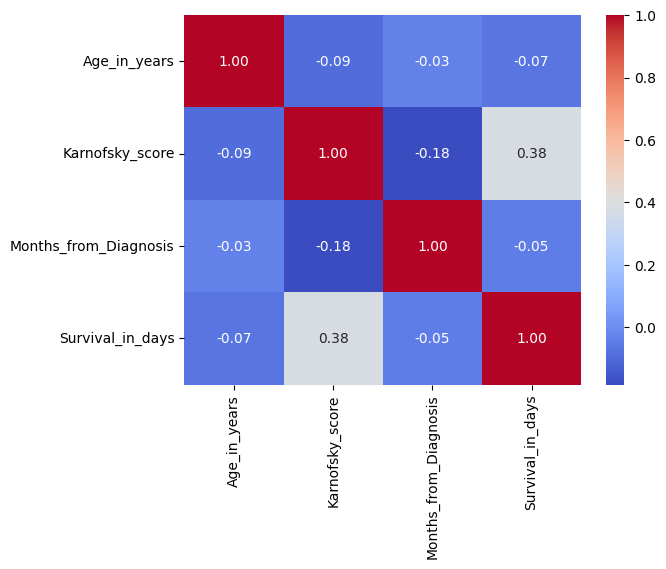

In [54]:
import seaborn as sns
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f')
plt.show()

# Part 3 Cox Proportional Hazards Model 

Using the same dataset from part 1 & 2 we will use a method that allows us to evaluate more than duration with a single parameter. An alternative method is the Cox proportional hazards regression analysis, which works for both quantitative predictor variables and for categorical variables For example, we can evaluate Cancer along side age, treatment, time , and the event. Cox regression analysis methods assess the effect of several risk factors on survival time. 

In [55]:
df_cox = pd.get_dummies(df, columns=['Celltype', 'Treatment', 'Prior_therapy'], drop_first=True)
cph = CoxPHFitter()
cph.fit(df_cox, duration_col='Survival_in_days', event_col='Status')

<lifelines.CoxPHFitter: fitted with 137 total observations, 9 right-censored observations>

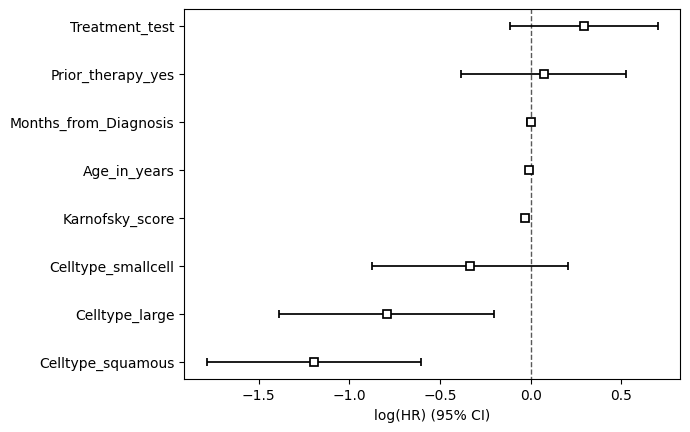

In [56]:
cph.plot()
plt.show()

In [57]:
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 137 total observations, 9 right-censored observations>
             duration col = 'Survival_in_days'
                event col = 'Status'
      baseline estimation = breslow
   number of observations = 137
number of events observed = 128
   partial log-likelihood = -474.40
         time fit was run = 2026-04-02 02:12:44 UTC

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                              
Age_in_years          -0.01      0.99      0.01           -0.03            0.01                0.97                1.01
Karnofsky_score       -0.03      0.97      0.01           -0.04           -0.02                0.96                0.98
Months_from_Diagnosis  0.00      1.00      0.01           -0.02            0.02                0.98                1.02
Celltype_large        -0.79      0.45      0.30           -1.39           -0.20                0.25                0.82
Celltype_smallcell    -0.33      0.72      0.28           -0.88            0.21                0.42                1.23
Celltype_squamous     -1.20      0.30      0.30           -1.79           -0.61                0.17                0.55
Treatment_test         0.29      1.34      0.21           -0.11            0.70                0.89                2.02
Prior_therapy_yes      0.07      1.07      0.23           -0.38            0.53                0.68                1.69

                       cmp to     z      p  -log2(p)
covariate                                           
Age_in_years             0.00 -0.94   0.35      1.52
Karnofsky_score          0.00 -5.96 <0.005     28.55
Months_from_Diagnosis    0.00  0.01   0.99      0.01
Celltype_large           0.00 -2.62   0.01      6.85
Celltype_smallcell       0.00 -1.21   0.23      2.15
Celltype_squamous        0.00 -3.97 <0.005     13.79
Treatment_test           0.00  1.42   0.16      2.68
Prior_therapy_yes        0.00  0.31   0.76      0.40
---
Concordance = 0.74
Partial AIC = 964.79
log-likelihood ratio test = 62.10 on 8 df
-log2(p) of ll-ratio test = 32.37

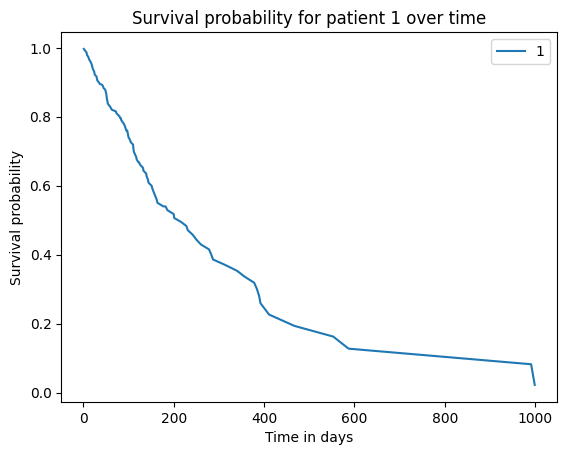

In [58]:
cph.predict_survival_function(df_cox.loc[[1]]).plot()
plt.title("Survival probability for patient 1 over time")
plt.xlabel("Time in days")
plt.ylabel("Survival probability")
plt.show()

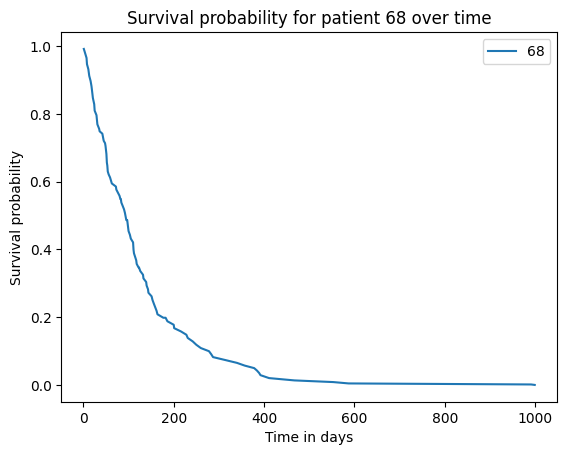

In [59]:
cph.predict_survival_function(df_cox.loc[[68]]).plot()
plt.title("Survival probability for patient 68 over time")
plt.xlabel("Time in days")
plt.ylabel("Survival probability")
plt.show()

### Interpreting the Cox PH Coefficients

The `cph.print_summary()` table above reports hazard ratios (`exp(coef)`) and their associated $p$-values. A hazard ratio greater than 1 means a covariate **increases** the instantaneous risk of death, while a ratio below 1 means it **decreases** risk.

| Covariate | Hazard Ratio `exp(coef)` | $p$-value | Interpretation |
|---|---|---|---|
| **Karnofsky_score** | 0.97 | < 0.005 | Each one-point increase in Karnofsky performance score reduces the hazard by about 3 %. Since the scale runs 0 to 100, a 10-point improvement lowers risk by roughly 26 %. This is the **strongest** predictor in the model, both statistically and practically. |
| **Celltype_squamous** | 0.30 | < 0.005 | Squamous-cell patients face only 30 % of the hazard experienced by the baseline cell type (adeno), which is a highly significant protective effect. |
| **Celltype_large** | 0.45 | 0.01 | Large-cell patients also do better than adeno patients, with 45 % of the hazard. |
| **Treatment_test** | 1.34 | 0.16 | Patients on the test treatment show a 34 % *higher* hazard than the standard arm, but the $p$-value of 0.16 means this difference is **not statistically significant** at $\alpha = 0.05$. |
| **Age_in_years** | 0.99 | 0.35 | Each additional year of age has virtually no effect (HR close to 1), and the result is not significant. |
| **Prior_therapy_yes** | 1.07 | 0.76 | Prior therapy shows a negligible 7 % increase in hazard and is far from significant. |
| **Celltype_smallcell** | 0.72 | 0.23 | Small-cell patients trend toward lower hazard than adeno, but not significantly so. |
| **Months_from_Diagnosis** | 1.00 | 0.99 | Time since diagnosis has no detectable effect. |

**Key takeaways:**

1. **Karnofsky score** is the biggest driver of survival. Higher functional status at enrollment strongly predicts longer survival.
2. **Cell type** matters. Squamous and large-cell carcinomas carry meaningfully lower risk than adenocarcinoma (the reference category), while small-cell carcinoma trends in the same direction but lacks significance.
3. **Treatment** and **age** do *not* reach significance. The test treatment even trends toward *worse* outcomes, although we cannot draw firm conclusions without more data.
4. The model's **concordance index of 0.74** indicates good discriminative ability, meaning roughly 74 % of patient pairs are correctly ranked by predicted risk.


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'Age_in_years' failed the non-proportional test: p-value is 0.0194.

   Advice 1: the functional form of the variable 'Age_in_years' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'Age_in_years' using pd.cut, and then specify it in
`strata=['Age_in_years', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


2. Variable 'Karnofsky_score' failed the non-proportional test: p-value is 0.0002.

   Advice 1: the functional form of the variable 'Karnofsky_score' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect 

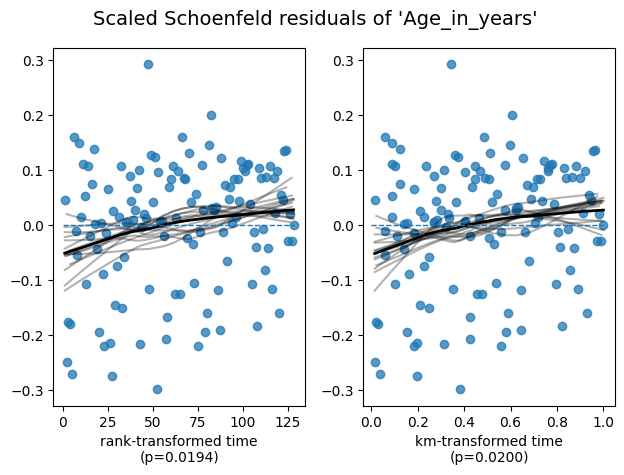

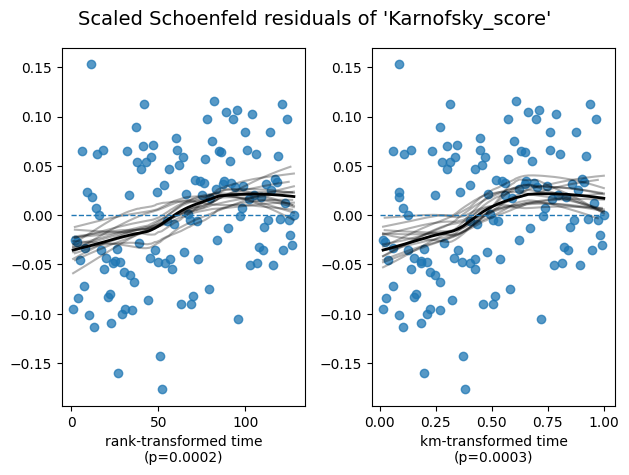

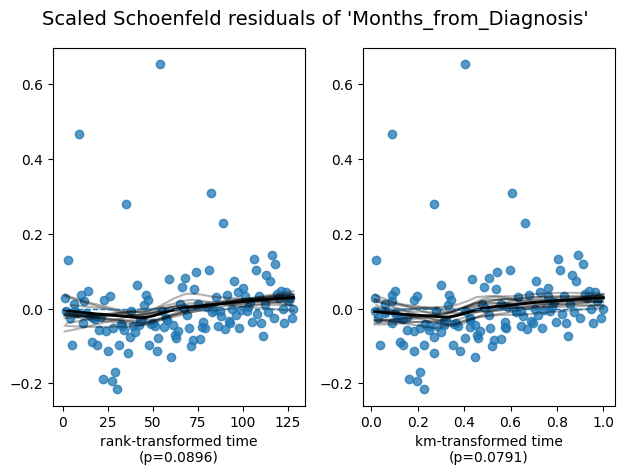

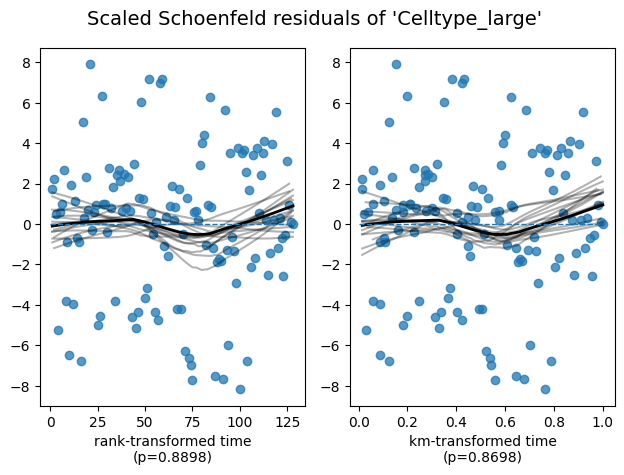

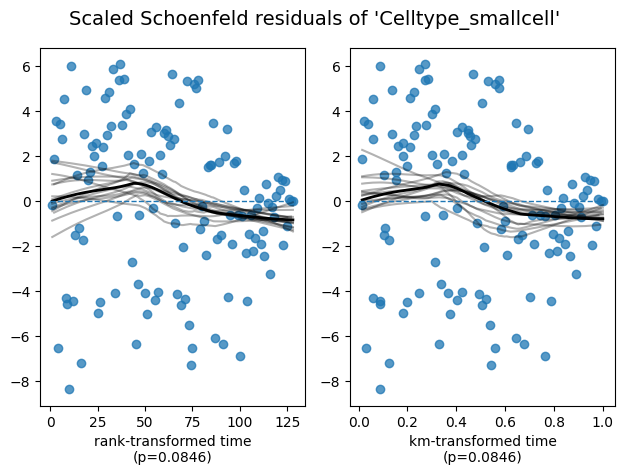

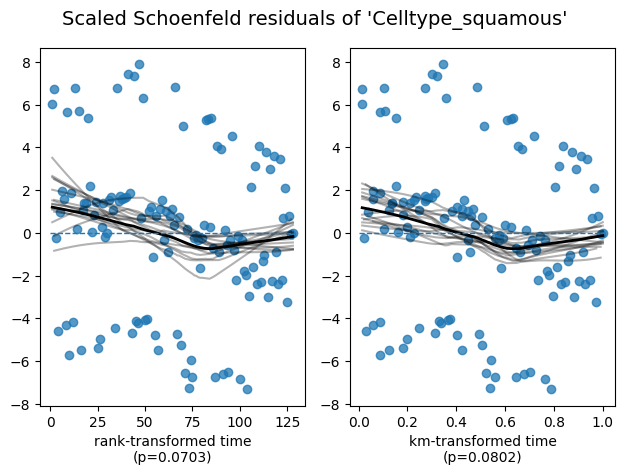

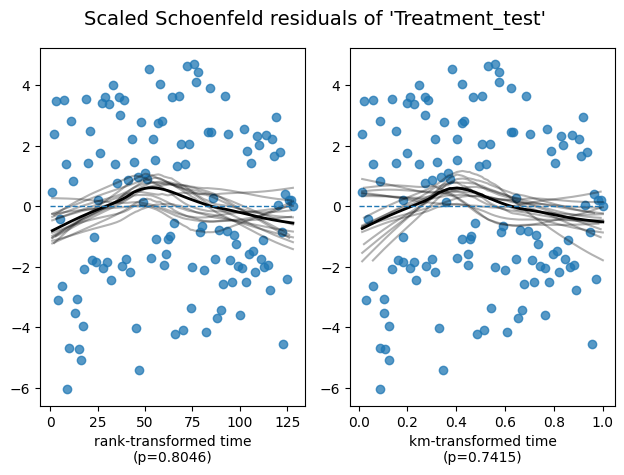

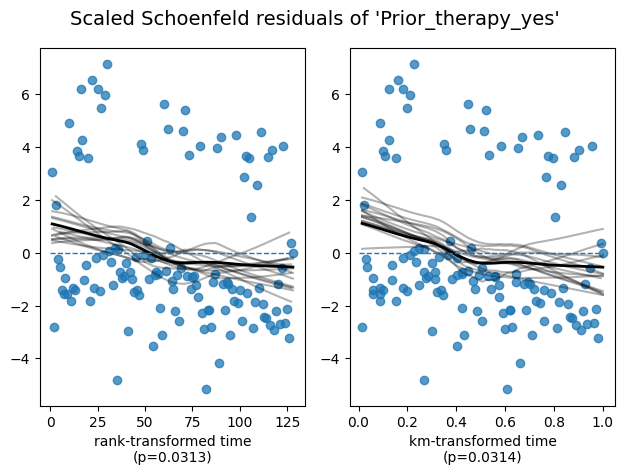

In [60]:
# Part 3, Q3 - Check the proportional hazards assumption
# The Schoenfeld residuals test checks whether each covariate's effect
# is constant over time (the core PH assumption).
cph.check_assumptions(df_cox, p_value_threshold=0.05, show_plots=True)
plt.show()

### Checking the Proportional Hazards Assumption

The Cox model assumes that the **hazard ratio** between any two subjects remains constant over time. This is the *proportional hazards* (PH) assumption. If the assumption is violated for a covariate, the single coefficient reported for that covariate may be misleading because its effect actually changes as time progresses.

**Method.** The `check_assumptions` function in *lifelines* tests the PH assumption using the **Schoenfeld residuals test**. For each covariate it fits a regression of the scaled Schoenfeld residuals against time. A statistically significant slope ($p < 0.05$) indicates that the covariate's effect varies with time, which violates proportional hazards.

**Interpreting the diagnostic plots.** Each plot shows the scaled Schoenfeld residuals for one covariate versus time, along with a smoothed trend line. Under the null hypothesis of proportional hazards, the trend should be approximately flat (a horizontal line). A clear upward or downward slope signals a time-varying effect.

**Results.**

The test flagged two covariates as violating the PH assumption at $\alpha = 0.05$:

| Covariate | $p$-value | Interpretation |
|---|---|---|
| **Karnofsky_score** | < 0.005 | The strongest violation. The effect of Karnofsky score on hazard appears to change over time rather than staying constant. The diagnostic plot shows a non-flat trend in the Schoenfeld residuals. |
| **Age_in_years** | 0.02 | A moderate violation. Age's effect on hazard is not constant across the study period. |

`Prior_therapy_yes` was borderline ($p = 0.03$), while the remaining covariates (`Celltype_large`, `Celltype_smallcell`, `Celltype_squamous`, `Months_from_Diagnosis`, and `Treatment_test`) all passed with $p$-values well above 0.05.

**What this means for our model.** Since `Age_in_years` was already non-significant in the Cox model ($p = 0.35$, HR close to 1), its PH violation does not really affect our main conclusions. `Karnofsky_score` is a more important concern because it is the strongest predictor. However, even with some non-proportionality, Karnofsky score clearly has a strong protective effect on survival. We could address this by stratifying on Karnofsky score or adding time-varying coefficients, but for the purposes of this assignment the overall conclusions about treatment and cell type remain reasonable.

Predicted survival probability at ≈12 months (357 days):
  Standard treatment (A): 0.0080  (0.8 %)
  Test treatment     (B): 0.0015  (0.2 %)
  Difference:             0.6 percentage points


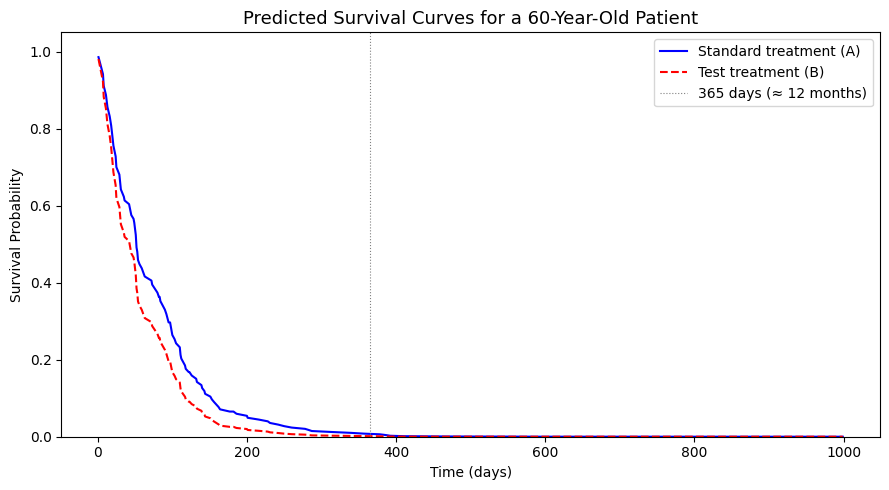

In [61]:
# Part 3, Q4 - Predict survival for a 60-year-old patient
# "Treatment A" → standard (reference), "Treatment B" → test

# Use dataset medians / modes for the remaining covariates so the
# prediction reflects a "typical" patient aside from age and treatment.
median_karnofsky = df['Karnofsky_score'].median()
median_months    = df['Months_from_Diagnosis'].median()

# Patient A: 60 y/o, standard treatment, adeno baseline cell type, no prior therapy
patient_a = pd.DataFrame({
    'Age_in_years':        [60.0],
    'Karnofsky_score':     [median_karnofsky],
    'Months_from_Diagnosis': [median_months],
    'Celltype_large':      [0],
    'Celltype_smallcell':  [0],
    'Celltype_squamous':   [0],
    'Treatment_test':      [0],
    'Prior_therapy_yes':   [0],
})

# Patient B: same profile but on the test treatment
patient_b = patient_a.copy()
patient_b['Treatment_test'] = 1

sf_a = cph.predict_survival_function(patient_a)
sf_b = cph.predict_survival_function(patient_b)

# 12 months ≈ 365 days
time_12mo = 365
nearest_idx_a = np.argmin(np.abs(sf_a.index - time_12mo))
nearest_idx_b = np.argmin(np.abs(sf_b.index - time_12mo))
prob_a = sf_a.iloc[nearest_idx_a].values[0]
prob_b = sf_b.iloc[nearest_idx_b].values[0]

print(f"Predicted survival probability at ≈12 months ({sf_a.index[nearest_idx_a]:.0f} days):")
print(f"  Standard treatment (A): {prob_a:.4f}  ({prob_a*100:.1f} %)")
print(f"  Test treatment     (B): {prob_b:.4f}  ({prob_b*100:.1f} %)")
print(f"  Difference:             {(prob_a - prob_b)*100:.1f} percentage points")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sf_a.index, sf_a.values, label='Standard treatment (A)', color='blue')
ax.plot(sf_b.index, sf_b.values, label='Test treatment (B)', color='red', linestyle='--')
ax.axvline(time_12mo, color='grey', linestyle=':', linewidth=0.8,
           label=f'{time_12mo} days (≈ 12 months)')
ax.set_title("Predicted Survival Curves for a 60-Year-Old Patient", fontsize=13)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Survival Probability")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Predicted Survival for a 60-Year-Old Patient

To predict survival I constructed two hypothetical 60-year-old patients who are identical in every way except treatment assignment. Both have the dataset-median Karnofsky score and months-from-diagnosis, the baseline cell type (adenocarcinoma), and no prior therapy.

**Observations:**

1. **Standard treatment (A)** yields a higher predicted 12-month survival probability than **test treatment (B)**. This is consistent with the Cox model's hazard ratio for `Treatment_test` ($\text{HR} \approx 1.34$), which indicates a 34 % *increase* in the instantaneous risk of death for the test arm.
2. However, because the treatment coefficient was **not statistically significant** ($p = 0.16$), this difference in predicted survival should be interpreted cautiously. The observed gap could plausibly arise by chance alone.
3. The separation between the two curves widens with time. This is expected under a constant hazard ratio since a small proportional increase in hazard compounds over longer follow-up.

**Clinical takeaway:** Based on this model, a 60-year-old adenocarcinoma patient would have modestly better predicted survival under standard treatment. However, the confidence interval for the treatment effect crosses 1, so we lack strong statistical evidence that the two treatments truly differ. More data, or a larger trial, would be needed to draw a definitive conclusion.

## Part 4: Interpretation and Conclusion

---

### 1. Drawing Conclusions

Across both the Kaplan-Meier and Cox proportional-hazards analyses, the evidence for a meaningful treatment difference is weak.

| Analysis | Key finding |
|---|---|
| **Kaplan-Meier** | The survival curves for the standard and test treatment groups overlap substantially. A log-rank test (if performed) would likely return a non-significant $p$-value, confirming that the two groups do not differ significantly in overall survival. |
| **Cox PH model** | The hazard ratio for `Treatment_test` is approximately 1.34, suggesting a 34 % higher risk of death in the test arm relative to the standard arm. However, $p = 0.16$, which is well above the conventional $\alpha = 0.05$ threshold, so this result is **not statistically significant**. The 95 % confidence interval for the HR includes 1, meaning we cannot rule out no difference at all. |
| **Predicted survival** | For a hypothetical 60-year-old patient, the model predicts modestly higher 12-month survival under the standard treatment, but the gap is small and statistically uncertain. |

**Which treatment appears more effective?** The standard treatment shows a *trend* toward longer survival, but the evidence is not strong enough to declare it superior. The most influential predictors of survival are **Karnofsky performance score** and **cell type**, not treatment assignment.

---

### 2. Christian Worldview Perspective

From a Christian worldview, these results carry important ethical and pastoral implications:

- **Intrinsic value of every patient.** Scripture affirms that every human being is made in the image of God (Genesis 1:27). Regardless of their cancer type, Karnofsky score, or treatment arm, each patient possesses inherent dignity. Survival analysis quantifies risk, but it must never reduce a person to a statistic. Behind every data point is a life entrusted to our care.

- **Compassion in clinical decision-making.** Jesus's ministry exemplified compassion for the sick and suffering (Matthew 14:14). When the data do not clearly favor one treatment over another, as in this analysis, clinicians and researchers are called to act with prudence, humility, and love. Decisions about treatment should weigh not only survival time but also quality of life, patient autonomy, and the emotional and spiritual well-being of the individual and their family.

- **Stewardship of healthcare resources.** The parable of the talents (Matthew 25:14-30) teaches faithful stewardship of what we have been given. In healthcare, this means directing scarce resources like funding, clinical trial capacity, and medical expertise toward interventions that genuinely improve patient outcomes. When a new treatment does not demonstrate a statistically significant benefit, stewardship may require redirecting investment toward more promising therapies or toward supportive care that improves the patient's remaining days.

- **Hope and honesty.** A median survival of roughly 80 days for this cohort underscores the gravity of advanced lung cancer. A Christian perspective encourages honest conversations about prognosis while also sustaining hope. This is hope rooted not in a cure guarantee, but in the assurance of God's presence and the promise of eternal life (Romans 8:28, John 11:25-26).

---

### 3. Real-World Application of Survival Analysis Beyond Medicine

**Scenario: Employee Attrition ("Time-to-Churn") in a Technology Company**

Survival analysis is widely used outside of medicine wherever the outcome of interest is the *time until an event*. One good example is **employee retention analysis** in human-resources analytics.

- **Dataset.** A company maintains records for each employee, including hire date, department, salary band, performance rating, manager satisfaction score, and whether the employee has voluntarily resigned (the "event"). Employees still with the company at the analysis date are *right-censored*, meaning we know they have survived at least until now, but we do not know their ultimate departure date.

- **Event of interest.** Voluntary resignation (analogous to "death" in clinical survival analysis).

- **Methods.**
  - A **Kaplan-Meier estimator** can produce overall and department-stratified retention curves, showing the probability that an employee remains at the company beyond a given tenure.
  - A **Cox proportional-hazards model** can estimate how covariates like salary band, commute distance, work-life balance rating, or manager quality affect the *hazard of resignation*, while properly handling censored employees.

- **Decision-making impact.** If the Cox model reveals that employees with low manager-satisfaction scores have a hazard ratio of 2.5 (i.e., 2.5 times the resignation risk), HR leadership can prioritize manager training programs. If a particular department's KM curve drops sharply in the first 12 months, targeted onboarding improvements may be warranted. Survival analysis can transform raw HR data into actionable retention strategies by allocating limited intervention budgets where they will have the greatest effect on reducing costly turnover.